# Классификация Iris-датасета различными методами с выдачей точности по каждому объекту

## Пролог

In [26]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


SEED = 42

# Загрузка данных, пример с набором данных Iris
data = load_iris()
X, y = data.data, data.target

## Подготовка данных и определение моделей. Разбивка на тренировочные и тестовые данные

In [27]:
# Разделите данные на обучающую и тестовую выборки 150: 120/30
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)
print(f"К-т разбиения {test_size}"
      f"\nВсего образцов {X.shape[0]}"
      f"\nТренировочных {X_train.shape[0]}"
      f"\nТестовых {X_test.shape[0]}")

К-т разбиения 0.3
Всего образцов 150
Тренировочных 105
Тестовых 45


In [28]:
@dataclass
class Model:
    model: BaseEstimator
    description: str

models = [
    Model(model=LogisticRegression(max_iter=1000, random_state=SEED), description="Logistic Regression"),
    Model(model=SVC(probability=True, random_state=SEED), description="SVM"),
    Model(model=RandomForestClassifier(random_state=SEED), description="Random Forests")
]

## Пора на тренировку! 🫡

In [29]:
for i, m in enumerate(models):
    m.model.fit(X_train, y_train)

## Оценка качества моделей

### Определение класса для тестовой выборки `y_pred` и сравнение и известными ожидаемыми значениями `y_test`

In [30]:
# results = {}

for m in models:
    # m.model.fit(X_train, y_train)     # модели уже натренированы в предыдущих шагах
    y_pred = m.model.predict(X_test)

    # Рассчитываем метрики
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    # results[m.description] = {
    #     'accuracy': accuracy,
    #     'report': report
    # }

    print(f"{m.description:30} {accuracy=:.0%}")
    if accuracy != 1.0:
        print("\nПодробный отчет:")
        print(report)

Logistic Regression            accuracy=100%
SVM                            accuracy=100%
Random Forests                 accuracy=100%


### Определение класса как вероятности ко всем классам `predict_proba`

#### Визуализация вероятностей классификации для каждой модели

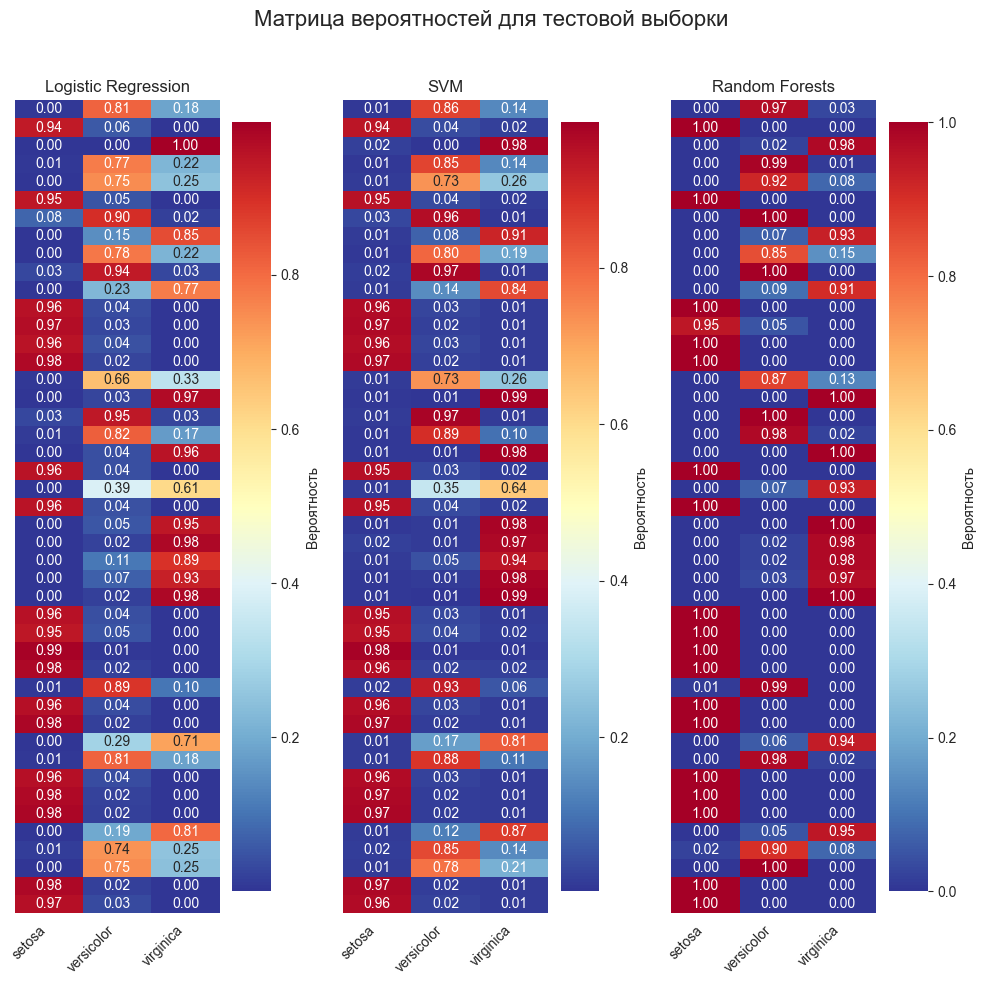

In [31]:
plt.figure(figsize=(10, 10))
plt.suptitle('Матрица вероятностей для тестовой выборки', fontsize=16)
class_names = data.target_names  # подписи классов: setosa, versicolor, virginica

for i, m in enumerate(models):
    probs = m.model.predict_proba(X_test)

    ax = plt.subplot(1, 3, i + 1)
    sns.heatmap(
        probs,
        annot=True,
        cmap='RdYlBu_r',
        fmt='.2f',
        # square=True,
        xticklabels=class_names,
        yticklabels=False,
        cbar_kws={'label': 'Вероятность'}
    )
    # ax.set_xlabel('Вид ириса')
    # ax.set_ylabel('Объекты тестовой выборки')
    ax.set_title(m.description)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Вычисление метрик оценки точности моделей

По матрицам `predict_proba` можно вычислять «пробабилистические» метрики, которые показывают, насколько хорошо модель оценивает именно вероятности, а не просто правильно/неправильно относит объект к классу. Самые распространённые:

1. Log-loss (кросс-энтропия, `sklearn.metrics.log_loss`) • Чем МЕНЬШЕ, тем лучше (идеал = 0).
2. Brier score (`sklearn.metrics.brier_score_loss` для бинарного случая, или усреднённый по классам в многоклассовой задаче). • Тоже «меньше = лучше».
3. ROC-AUC / PR-AUC
• В многоклассовой задаче считаем «one-vs-rest» (`average='macro'` или `'weighted'`);
• Чем БОЛЬШЕ, тем лучше (идеал = 1).
4. Expected Calibration Error (ECE) — нет сразу в sklearn, но есть в `sktime`/`torchmetrics`/`scikit-calibration`.



In [32]:
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

n_classes = len(np.unique(y_train))

for m in models:
    probs = m.model.predict_proba(X_test)
    y_pred = probs.argmax(1)

    print(f'\n{m.description}')
    print(f' accuracy        : {accuracy_score(y_test, y_pred):.3f}')
    print(f' log-loss        : {log_loss(y_test, probs):.3f}')

    # Brier: усредняем по классам
    brier = np.mean([brier_score_loss((y_test == k).astype(int), probs[:, k])
                     for k in range(n_classes)])
    print(f' brier score     : {brier:.3f}')

    # ROC-AUC macro ovo
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    auc = roc_auc_score(y_test_bin, probs, average='macro', multi_class='ovo')
    print(f' ROC-AUC (macro) : {auc:.3f}')


Logistic Regression
 accuracy        : 1.000
 log-loss        : 0.115
 brier score     : 0.013
 ROC-AUC (macro) : 1.000

SVM
 accuracy        : 1.000
 log-loss        : 0.090
 brier score     : 0.008
 ROC-AUC (macro) : 1.000

Random Forests
 accuracy        : 1.000
 log-loss        : 0.024
 brier score     : 0.001
 ROC-AUC (macro) : 1.000


## Выводы по оценке точности моделей

По log-loss и Brier-score Random Forest наиболее калиброван, у SVM – средний результат, у логистической регрессии – худший, несмотря на одинаковую accuracy
